# Two-dimensional Wave equation example

This notebook runs the existing Weak-PDE-Net Wave pipeline, records one representative result after each discovery stage, and displays the final field reconstruction with the project's standard plotting function.

All model and training hyperparameters are loaded directly from `Wave_2d_mains/wave_params.py`. Only the sampling ratio, noise level, and optional number of sampling points are selected below.

> To retain all stage summaries and the final figure in this file when running from the command line, execute the notebook with `jupyter nbconvert --execute --to notebook --inplace 2D_example.ipynb`.

In [1]:
from contextlib import redirect_stderr, redirect_stdout
from pathlib import Path
import os
import sys

import numpy as np
import torch
from IPython.display import Image, display

# Locate the repository whether Jupyter starts here or in a subdirectory.
current_dir = Path.cwd().resolve()
project_candidates = [current_dir, *current_dir.parents]
PROJECT_ROOT = next(
    (path for path in project_candidates if (path / 'PDE_Discover.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the repository or Wave_2d_mains directory.')

WAVE_DIR = PROJECT_ROOT / 'Wave_2d_mains'
for path in (PROJECT_ROOT, PROJECT_ROOT / 'params', WAVE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.chdir(WAVE_DIR)

from wave import get_incremental_sampling_idx, load_wave_data, set_all_seeds
from wave_params import Params
from PDE_Discover import PDE_Discover
from Tune_Net import evaluate_test_mse
from plot_pde import plot_3d

## 1. Reproduction settings

The three inputs below match the command-line controls in `Wave_2d_mains/wave.py`. `SAMPLE_POINTS` overrides `SAMPLE_RATIO` when it is not `None`; all remaining parameters come unchanged from `wave_params.py`.

In [2]:
SAMPLE_RATIO = 0.15
NOISE_LEVEL = 0.0
SAMPLE_POINTS = None
config = Params()
SEED = int(getattr(config, 'seed', 42))
set_all_seeds(SEED)

## 2. Load and sample the Wave data

In [3]:
coordinates, values, input_data, grid_shape = load_wave_data()
total_points = len(values)
if not 0 < SAMPLE_RATIO <= 1:
    raise ValueError('SAMPLE_RATIO must be in the interval (0, 1].')

if SAMPLE_POINTS is None:
    sample_points = int(total_points * SAMPLE_RATIO)
    sample_ratio = SAMPLE_RATIO
else:
    if not 0 < SAMPLE_POINTS <= total_points:
        raise ValueError(f'SAMPLE_POINTS must be between 1 and {total_points}.')
    sample_points = int(SAMPLE_POINTS)
    sample_ratio = sample_points / total_points

config.sample_ratio = sample_ratio
config.sigma_NR = NOISE_LEVEL
with open(os.devnull, 'w') as quiet_output, redirect_stdout(quiet_output):
    sampling_idx = get_incremental_sampling_idx(
        total_points,
        sample_ratio,
        save_dir=str(WAVE_DIR / 'sampling_idx' / 'reviewer_demo'),
        seed=SEED,
        target_size=sample_points,
    )

coordinates_train = torch.tensor(
    coordinates[sampling_idx], dtype=torch.float32, requires_grad=True
)
values_train = torch.tensor(values[sampling_idx], dtype=torch.float32)
if NOISE_LEVEL > 0:
    noise_scale = NOISE_LEVEL * torch.sqrt(torch.mean(values_train ** 2))
    values_train = values_train + torch.randn_like(values_train) * noise_scale
input_train = torch.cat((coordinates_train, values_train), dim=1)

## 3. Run the discovery pipeline

The complete Searching and Pruning workflow is executed without changing its internal logic. The current Wave parameters set `n_epochs_tune = 0`, so the notebook explicitly reports that Tuning is skipped while retaining the final post-pruning equation and project test loss.

In [4]:
stage_results = {}
coordinate_tensor = torch.tensor(coordinates, dtype=torch.float32)
reference_vector = values.reshape(-1)

def predict_field(current_solver):
    was_training = current_solver.Pig_Net.training
    current_solver.Pig_Net.eval()
    batches = []
    with torch.no_grad():
        for batch in coordinate_tensor.split(8192):
            batches.append(
                current_solver.Pig_Net(
                    batch.to(current_solver.Device), current_solver.norm_flag
                ).cpu()
            )
    if was_training:
        current_solver.Pig_Net.train()
    return torch.cat(batches, dim=0).numpy().reshape(-1)

def project_test_loss(current_solver):
    return evaluate_test_mse(
        current_solver.Pig_Net,
        current_solver.inputs_test,
        current_solver.problem_dim,
        current_solver.Device,
        current_solver.norm_flag,
    )

with open(os.devnull, 'w') as quiet_output:
    with redirect_stdout(quiet_output), redirect_stderr(quiet_output):
        solver = PDE_Discover(config, input_data=input_train, inputs_test=input_data)

original_nas = solver.NAS_Sym_Net
def tracked_nas():
    result = original_nas()
    beta_list, alphas_list, _, _, _ = result
    operator_names = [operator.__class__.__name__ for operator in solver.funcs]
    selected_architectures = []
    for equation_index, (beta, equation_alphas) in enumerate(zip(beta_list, alphas_list)):
        depth = solver.depth_candidates[int(np.argmax(np.asarray(beta)))]
        layers = []
        for layer_alphas in equation_alphas[:depth]:
            repeats = {}
            for operator_index, (name, alpha) in enumerate(zip(operator_names, layer_alphas)):
                candidate_index = int(np.argmax(np.asarray(alpha)))
                repeats[name] = int(solver.repeats_candidates[operator_index][candidate_index])
            layers.append(repeats)
        selected_architectures.append(
            {'equation': equation_index + 1, 'depth': depth, 'layers': layers}
        )
    stage_results['Searching'] = {
        'architectures': selected_architectures,
        'test_loss': project_test_loss(solver),
    }
    return result
solver.NAS_Sym_Net = tracked_nas

original_final_train = solver.final_train
def tracked_final_train():
    result = original_final_train()
    sparse_equations = []
    for equation_index, payload in sorted(result.items()):
        loss = payload['total_loss']
        if torch.is_tensor(loss):
            loss = loss.detach().cpu().item()
        sparse_equations.append({
            'equation': equation_index + 1,
            'pde': str(np.asarray(payload['pde'], dtype=object).reshape(-1)[0]),
            'total_loss': float(loss),
        })
    stage_results['Pruning'] = {
        'equations': sparse_equations,
        'test_loss': project_test_loss(solver),
    }
    return result
solver.final_train = tracked_final_train

with open(os.devnull, 'w') as quiet_output:
    with redirect_stdout(quiet_output), redirect_stderr(quiet_output):
        final_pdes = solver.Solve_problem()

prediction = predict_field(solver)
stage_results['Tuning'] = {
    'enabled': config.n_epochs_tune > 0,
    'equations': final_pdes,
    'test_loss': project_test_loss(solver),
}

print('Searching completed:')
for architecture in stage_results['Searching']['architectures']:
    print(f"  Equation {architecture['equation']}: depth = {architecture['depth']}")
    for layer_index, repeats in enumerate(architecture['layers'], start=1):
        selected = ', '.join(
            f'{name} x {count}' for name, count in repeats.items() if count > 0
        ) or 'none'
        print(f'    Layer {layer_index}: {selected}')
print(f"  Test loss: {stage_results['Searching']['test_loss']:.3e}")

print('\nPruning completed:')
for result in stage_results['Pruning']['equations']:
    print(f"  Equation {result['equation']}: {result['pde']}")
    print(f"  Total loss: {result['total_loss']:.3e}")
print(f"  Test loss: {stage_results['Pruning']['test_loss']:.3e}")

if stage_results['Tuning']['enabled']:
    print('\nTuning completed:')
else:
    print('\nTuning skipped because n_epochs_tune = 0; final equation:')
for pde in stage_results['Tuning']['equations']:
    print(f'  {pde}')
print(f"  Test loss: {stage_results['Tuning']['test_loss']:.3e}")

Searching completed:
  Equation 1: depth = 2
    Layer 1: Identity x 3, Square x 2
    Layer 2: Identity x 3
  Test loss: 1.264e-02

Pruning completed:
  Equation 1: 0.77314*D_x^2 (1.29272*u) - 0.773348*D_y^2 (-1.29047*u)
  Total loss: 2.583e-03
  Test loss: 1.822e-03

Tuning completed:
  D_tt(u)=0.9995010693997476*D_y^2 (u)+1.0004314326518582*D_x^2 (u)
  Test loss: 3.451e-04


## 4. Final result and visualization

The project function `plot_3d()` saves the complete sequence of time slices. The notebook embeds the middle generated slice as a representative final result.

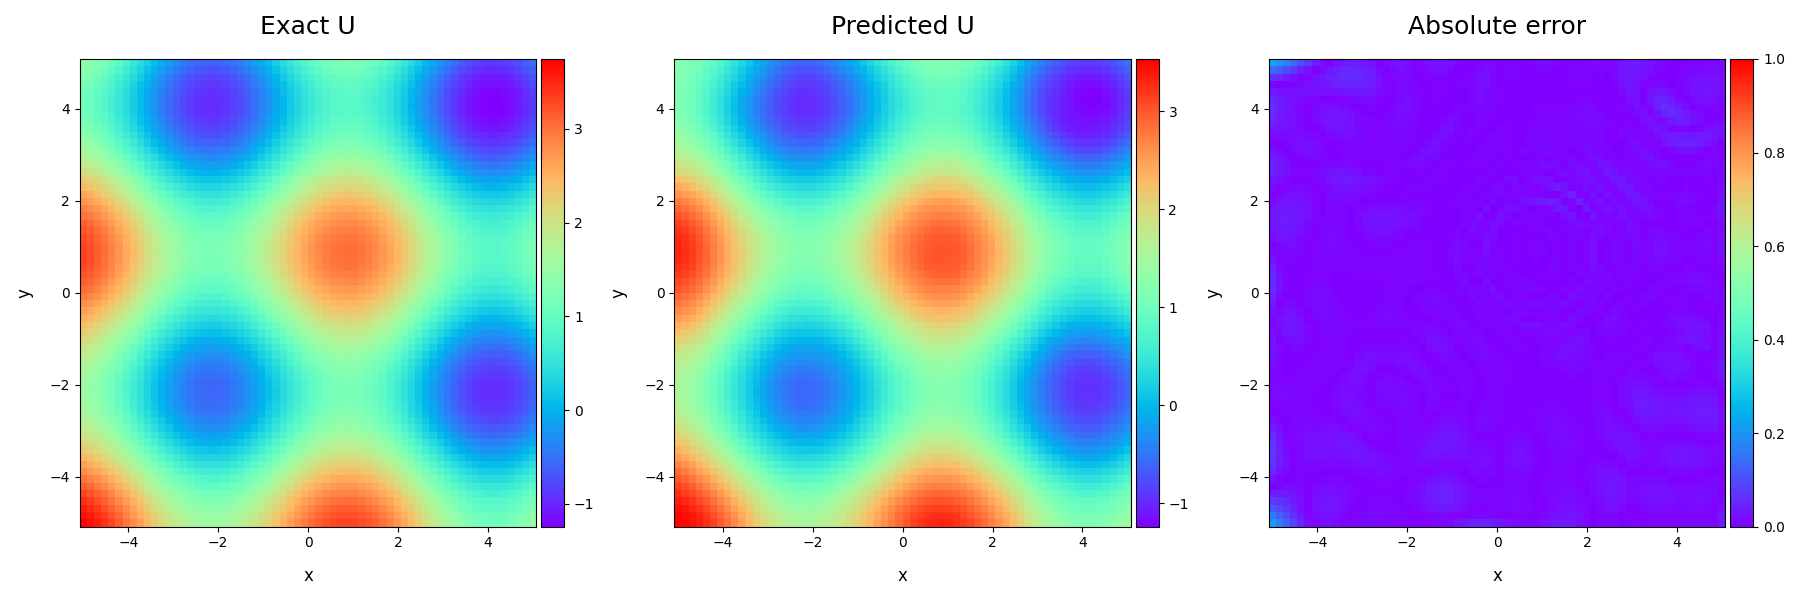

In [5]:
plot_tag = 'Wave_final'
plot_output_dir = Path(solver.subfolder_paths['tune'])
plot_3d(
    epoch=0,
    x=torch.tensor(coordinates[:, 1], dtype=torch.float32),
    y=torch.tensor(coordinates[:, 2], dtype=torch.float32),
    u_gt_all=torch.tensor(reference_vector, dtype=torch.float32),
    u_pred_all=torch.tensor(prediction, dtype=torch.float32),
    t=torch.tensor(coordinates[:, 0], dtype=torch.float32),
    grid_size=config.grid_plot_size,
    output_path=str(plot_output_dir),
    tag=plot_tag,
    step=config.time_step,
)
saved_time_indices = list(range(0, config.grid_plot_size[0], config.time_step))
representative_index = saved_time_indices[len(saved_time_indices) // 2]
plot_path = (
    plot_output_dir
    / f'{plot_tag}_0'
    / f'{plot_tag}_t{representative_index}_{representative_index}.png'
)
display(Image(filename=str(plot_path)))